In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import MDAnalysis
import mdtraj as md

import tqdm
import os

/Users/jesucastin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/MDAnalysis/topology/TPRParser.py:161: DeprecationWarning: 'xdrlib' is deprecated and slated for removal in Python 3.13
  import xdrlib


In [2]:

prefix_path='../../../LC3_MAIN_TRAJECTORIES/PROTEIN_ONLY_FITTED'

#UNB WT
u_unbound_ER_S1 = md.load_pdb("%s/LC3B_II_ER_protein/LC3B_II_ER_protein_SIM1_dt1000.pdb"%prefix_path)
u_unbound_ER_S2 =md.load_pdb("%s/LC3B_II_ER_protein/LC3B_II_ER_protein_SIM2_dt1000.pdb"%prefix_path)
u_unbound_ER_S3=md.load_pdb("%s/LC3B_II_ER_protein/LC3B_II_ER_protein_SIM3_dt1000.pdb"%prefix_path)


In [3]:
u_unbound_ER_MUT1=md.load_xtc('/Volumes/PortableSSD/LC3B_DATA_/new_test_mutant_sims/M1_M2_in_silico_mutations_fitted/M1_ER_concat_compact_center_fitted_dt1000.xtc',
                                          '/Volumes/PortableSSD/LC3B_DATA_/new_test_mutant_sims/M1_M2_in_silico_mutations_fitted/M1_ER_concat_compact_center_fitted_0ns.gro')
u_unbound_ER_MUT2=md.load_xtc('/Volumes/PortableSSD/LC3B_DATA_/new_test_mutant_sims/M1_M2_in_silico_mutations_fitted/M2_ER_concat_compact_center_fitted_dt1000.xtc',
                                         '/Volumes/PortableSSD/LC3B_DATA_/new_test_mutant_sims/M1_M2_in_silico_mutations_fitted/M2_ER_concat_compact_center_fitted_0ns.gro')



In [4]:
sec_struc_s1_unb=md.compute_dssp(u_unbound_ER_S1, simplified=True)
sec_struc_s2_unb=md.compute_dssp(u_unbound_ER_S2, simplified=True)
sec_struc_s3_unb=md.compute_dssp(u_unbound_ER_S3, simplified=True)

In [5]:
sec_struc_m1=md.compute_dssp(u_unbound_ER_MUT1, simplified=True)
sec_struc_m2=md.compute_dssp(u_unbound_ER_MUT2, simplified=True)

In [6]:
sec_struc_s1_unb_df=pd.DataFrame(sec_struc_s1_unb)
sec_struc_s2_unb_df=pd.DataFrame(sec_struc_s2_unb)
sec_struc_s3_unb_df=pd.DataFrame(sec_struc_s3_unb)

sec_struc_m1_df=pd.DataFrame(sec_struc_m1)
sec_struc_m2_df=pd.DataFrame(sec_struc_m2)



In [7]:
def dssp_df_procc(sec_struc_df):
    sec_struc_df=sec_struc_df.replace('C',2)
    sec_struc_df=sec_struc_df.replace('E',1)
    sec_struc_df=sec_struc_df.replace('H',0)
    
    #del sec_struc_df[118]
    sec_struc_df.columns=[i for i in range(1,120)]
    return sec_struc_df

In [8]:


sec_struc_s1_unb_proc=dssp_df_procc(sec_struc_s1_unb_df)
sec_struc_s2_unb_proc=dssp_df_procc(sec_struc_s2_unb_df)
sec_struc_s3_unb_proc=dssp_df_procc(sec_struc_s3_unb_df)

sec_struc_m1_proc=dssp_df_procc(sec_struc_m1_df)
sec_struc_m2_proc=dssp_df_procc(sec_struc_m2_df)


/var/folders/pp/z1pgcq157pjgg48m2cg7wwkh0000gn/T/ipykernel_33967/3451893596.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sec_struc_df=sec_struc_df.replace('C',2)
/var/folders/pp/z1pgcq157pjgg48m2cg7wwkh0000gn/T/ipykernel_33967/3451893596.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sec_struc_df=sec_struc_df.replace('E',1)
/var/folders/pp/z1pgcq157pjgg48m2cg7wwkh0000gn/T/ipykernel_33967/3451893596.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain th

In [9]:
def sec_struc_fraction(res_sec_struc):
    '''
    Simple 2D assignments
    0-->Helix
    1-->Sheet
    2-->Coil
    
    Returns fraction of time points a residue has formed a helix,
    sheet, coil
    '''
    f_h=res_sec_struc.count(0)/len(res_sec_struc)
    f_s=res_sec_struc.count(1)/len(res_sec_struc)
    f_c=res_sec_struc.count(2)/len(res_sec_struc)
    
    return(f_h, f_s, f_c)

def SEC_FRAC_COLL(sec_struc_df):
    f_h_ls=[]
    f_s_ls=[]
    f_c_ls=[]

    for i in sec_struc_df:
        ss_ls=sec_struc_df[i].to_list()
        ss_frac=sec_struc_fraction(ss_ls)
        f_h_ls.append(ss_frac[0])
        f_s_ls.append(ss_frac[1])
        f_c_ls.append(ss_frac[2])
    
    frac_df=pd.DataFrame([f_h_ls, f_s_ls, f_c_ls])
    frac_df=frac_df.transpose()
    return (frac_df)

In [10]:
unb_s1=SEC_FRAC_COLL(sec_struc_s1_unb_proc)
unb_s2=SEC_FRAC_COLL(sec_struc_s2_unb_proc)
unb_s3=SEC_FRAC_COLL(sec_struc_s3_unb_proc)

m1=SEC_FRAC_COLL(sec_struc_m1_proc)
m2=SEC_FRAC_COLL(sec_struc_m2_proc)



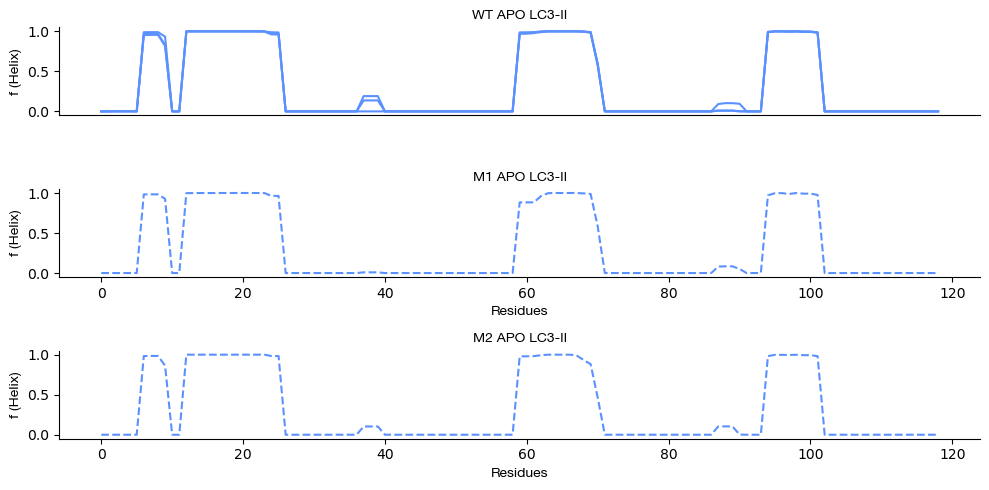

In [11]:
font = {'family':'helvetica neue',
    'color':  'black',
    'weight': 'bold',
    'size': 10
    }
rs={'family':'helvetica neue',
    'size':10
   }

fig, ax = plt.subplots(3, 1, figsize=(10, 5))
ax[0].plot(unb_s1[0], color='#5A91FF')
ax[0].plot(unb_s2[0], color='#5A91FF')
ax[0].plot(unb_s3[0], color='#5A91FF')

ax[0].tick_params(labelsize=10)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].set_xticks([],[])

ax[0].set_title('WT APO LC3-II', fontdict=font)
ax[0].set_ylabel('f (Helix)', fontdict=font)


ax[1].plot(m1[0], color='#5A91FF',ls='--')
ax[1].tick_params(labelsize=10)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)


ax[1].set_title('M1 APO LC3-II', fontdict=font)
ax[1].set_xlabel('Residues', fontdict=font)
ax[1].set_ylabel('f (Helix)', fontdict=font)


ax[2].plot(m2[0], color='#5A91FF',ls='--')
ax[2].tick_params(labelsize=10)
ax[2].spines['top'].set_visible(False)
ax[2].spines['right'].set_visible(False)


ax[2].set_title('M2 APO LC3-II', fontdict=font)
ax[2].set_xlabel('Residues', fontdict=font)
ax[2].set_ylabel('f (Helix)', fontdict=font)

fig.tight_layout() 

# plt.savefig('FRACTION_OF_helix.png', dpi=450, 
#             bbox_inches='tight', transparent=True)

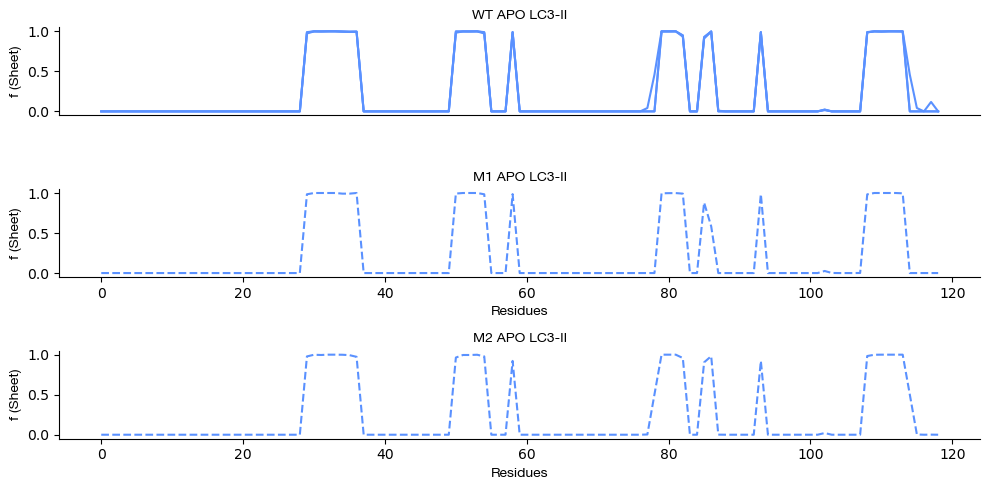

In [12]:
font = {'family':'helvetica neue',
    'color':  'black',
    'weight': 'bold',
    'size': 10
    }
rs={'family':'helvetica neue',
    'size':10
   }

fig, ax = plt.subplots(3, 1, figsize=(10, 5))
ax[0].plot(unb_s1[1], color='#5A91FF')
ax[0].plot(unb_s2[1], color='#5A91FF')
ax[0].plot(unb_s3[1], color='#5A91FF')

ax[0].tick_params(labelsize=10)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].set_xticks([],[])

ax[0].set_title('WT APO LC3-II', fontdict=font)
ax[0].set_ylabel('f (Sheet)', fontdict=font)


ax[1].plot(m1[1], color='#5A91FF',ls='--')
ax[1].tick_params(labelsize=10)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)


ax[1].set_title('M1 APO LC3-II', fontdict=font)
ax[1].set_xlabel('Residues', fontdict=font)
ax[1].set_ylabel('f (Sheet)', fontdict=font)


ax[2].plot(m2[1], color='#5A91FF',ls='--')
ax[2].tick_params(labelsize=10)
ax[2].spines['top'].set_visible(False)
ax[2].spines['right'].set_visible(False)


ax[2].set_title('M2 APO LC3-II', fontdict=font)
ax[2].set_xlabel('Residues', fontdict=font)
ax[2].set_ylabel('f (Sheet)', fontdict=font)

fig.tight_layout() 

# plt.savefig('FRACTION_OF_helix.png', dpi=450, 
#             bbox_inches='tight', transparent=True)

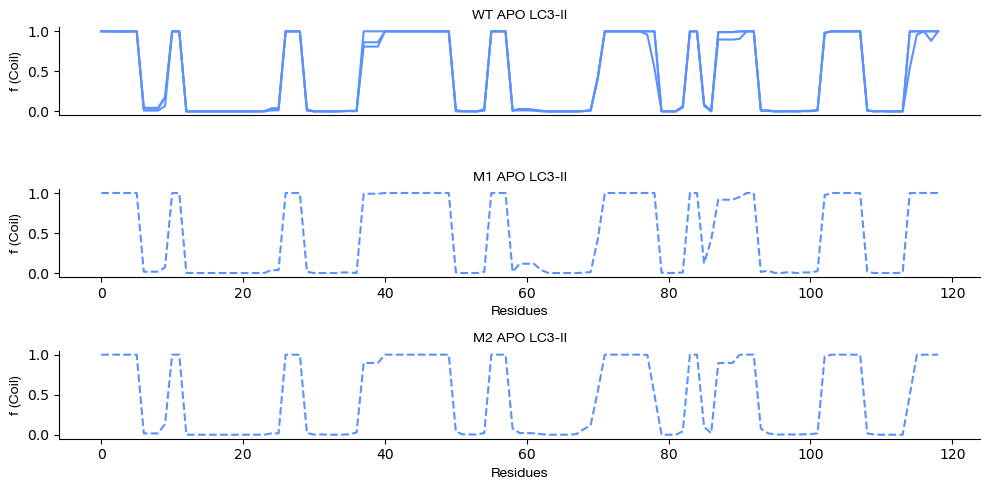

In [13]:
font = {'family':'helvetica neue',
    'color':  'black',
    'weight': 'bold',
    'size': 10
    }
rs={'family':'helvetica neue',
    'size':10
   }

fig, ax = plt.subplots(3, 1, figsize=(10, 5))
ax[0].plot(unb_s1[2], color='#5A91FF')
ax[0].plot(unb_s2[2], color='#5A91FF')
ax[0].plot(unb_s3[2], color='#5A91FF')

ax[0].tick_params(labelsize=10)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].set_xticks([],[])

ax[0].set_title('WT APO LC3-II', fontdict=font)
ax[0].set_ylabel('f (Coil)', fontdict=font)


ax[1].plot(m1[2], color='#5A91FF',ls='--')
ax[1].tick_params(labelsize=10)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)


ax[1].set_title('M1 APO LC3-II', fontdict=font)
ax[1].set_xlabel('Residues', fontdict=font)
ax[1].set_ylabel('f (Coil)', fontdict=font)


ax[2].plot(m2[2], color='#5A91FF',ls='--')
ax[2].tick_params(labelsize=10)
ax[2].spines['top'].set_visible(False)
ax[2].spines['right'].set_visible(False)


ax[2].set_title('M2 APO LC3-II', fontdict=font)
ax[2].set_xlabel('Residues', fontdict=font)
ax[2].set_ylabel('f (Coil)', fontdict=font)

fig.tight_layout() 

# plt.savefig('FRACTION_OF_helix.png', dpi=450, 
#             bbox_inches='tight', transparent=True)

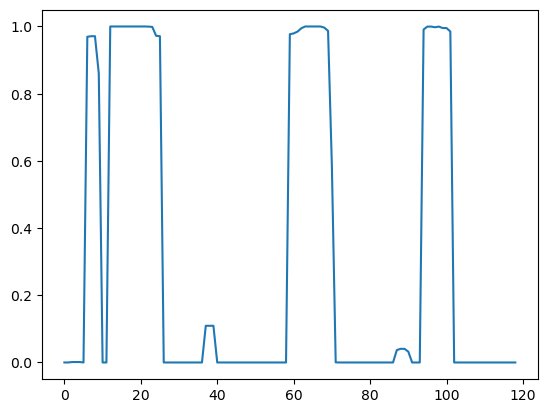

In [14]:
# plt.plot((unb_s1[0]+unb_s2[0]+unb_s3[0])/3)
plt.plot(((unb_s1[0]*1001)+(unb_s2[0]*1001)+(unb_s3[0]*1001))/3003)

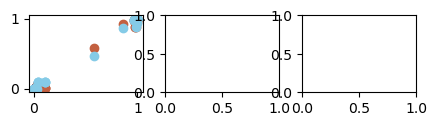

In [15]:
font = {'family':'helvetica neue',
    'color':  'black',
    'weight': 'bold',
    'size': 10
    }
rs={'family':'helvetica neue',
    'size':10
   }

fig, ax = plt.subplots(1, 3, figsize=(5,1))
#'#C36040','#85CBE7'

ax[0].scatter(((unb_s1[0]*1001)+(unb_s2[0]*1001)+(unb_s3[0]*1001))/3003,
             m1[0],color='#C36040')
ax[0].scatter(((unb_s1[0]*1001)+(unb_s2[0]*1001)+(unb_s3[0]*1001))/3003,
             m2[0],color='#85CBE7')

In [16]:
import scipy
f_hel_WT_M1=scipy.stats.pearsonr(((unb_s1[0]*1001)+(unb_s2[0]*1001)+(unb_s3[0]*1001))/3003,
                    m1[0])
f_hel_WT_M2=scipy.stats.pearsonr(((unb_s1[0]*1001)+(unb_s2[0]*1001)+(unb_s3[0]*1001))/3003,
                    m2[0])

In [17]:
f_sheet_WT_M1=scipy.stats.pearsonr(((unb_s1[1]*1001)+(unb_s2[1]*1001)+(unb_s3[1]*1001))/3003,
                    m1[1])
f_sheet_WT_M2=scipy.stats.pearsonr(((unb_s1[1]*1001)+(unb_s2[1]*1001)+(unb_s3[1]*1001))/3003,
                    m2[1])

In [18]:
f_coil_WT_M1=scipy.stats.pearsonr(((unb_s1[2]*1001)+(unb_s2[2]*1001)+(unb_s3[2]*1001))/3003,
                    m1[2])
f_coil_WT_M2=scipy.stats.pearsonr(((unb_s1[2]*1001)+(unb_s2[2]*1001)+(unb_s3[2]*1001))/3003,
                    m2[2])

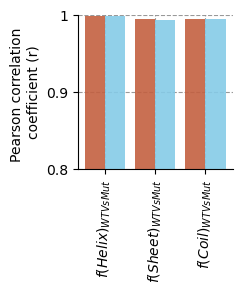

In [19]:
ss_ = ['Helix', 'Sheet', 'Coil' ] # categories
m1_ls, m2_ls = [f_hel_WT_M1[0],f_sheet_WT_M1[0],f_coil_WT_M1[0]],\
[f_hel_WT_M2[0],f_sheet_WT_M2[0],f_coil_WT_M2[0]]

# Bar width and x locations
w, x = 0.4, np.arange(len(ss_))

fig, ax = plt.subplots(figsize=(2,2))
ax.bar(x - w/2, m1_ls, width=w,color='#C36040',alpha=0.9)
ax.bar(x + w/2, m2_ls, width=w,color='#85CBE7',alpha=0.9)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.8)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.8)


ax.set_ylim(0.8,1)

ax.set_yticks([0.8,0.9,1],[0.8,0.9,1])
ax.set_xticks([0,1,2],[0,1,2])
ax.set_xticklabels(["$f(Helix)_{WT Vs Mut}$","$f(Sheet)_{WT Vs Mut}$",
                           "$f(Coil)_{WT Vs Mut}$"],rotation=90)
ax.set_ylabel("Pearson correlation \ncoefficient (r)")
plt.savefig("../../plots/TRIAD_MUTANT_CANDIDATES/f_ss_structures_WT_and_mutants.png",
           dpi=450,transparent=True, bbox_inches="tight")

In [20]:
f_hel_WT_M1, f_hel_WT_M2

(PearsonRResult(statistic=0.9985981434801243, pvalue=3.484314238161508e-151),
 PearsonRResult(statistic=0.9991125587056036, pvalue=8.559448652515439e-163))

In [21]:
f_sheet_WT_M1,f_sheet_WT_M2

(PearsonRResult(statistic=0.9946093073445033, pvalue=5.1536882195978705e-117),
 PearsonRResult(statistic=0.9936837450662689, pvalue=5.326055355148225e-113))

In [22]:
f_coil_WT_M1,f_coil_WT_M2

(PearsonRResult(statistic=0.9949315260101784, pvalue=1.4131680765553316e-118),
 PearsonRResult(statistic=0.9945941234986998, pvalue=6.072839797740202e-117))

In [27]:
WT_SS_elements_df=pd.DataFrame()
WT_SS_elements_df["Residues"]=[i for i in range(1,120)]
WT_SS_elements_df["f(helix)"]=((unb_s1[0]*1001)+(unb_s2[0]*1001)+(unb_s3[0]*1001))/3003
WT_SS_elements_df["f(sheet)"]=((unb_s1[1]*1001)+(unb_s2[1]*1001)+(unb_s3[1]*1001))/3003
WT_SS_elements_df["f(coil)"]=((unb_s1[2]*1001)+(unb_s2[2]*1001)+(unb_s3[2]*1001))/3003
WT_SS_elements_df.to_csv("../../../LC3_paper_data_files_for_source_data_comp/WT_unb_SS_fractions.csv")

In [28]:
M1_SS_elements_df=pd.DataFrame()
M1_SS_elements_df["Residues"]=[i for i in range(1,120)]
M1_SS_elements_df["f(helix)"]=m1[0]
M1_SS_elements_df["f(sheet)"]=m1[1]
M1_SS_elements_df["f(coil)"]=m1[2]
M1_SS_elements_df.to_csv("../../../LC3_paper_data_files_for_source_data_comp/M1_unb_SS_fractions.csv")

In [29]:
M2_SS_elements_df=pd.DataFrame()
M2_SS_elements_df["Residues"]=[i for i in range(1,120)]
M2_SS_elements_df["f(helix)"]=m2[0]
M2_SS_elements_df["f(sheet)"]=m2[1]
M2_SS_elements_df["f(coil)"]=m2[2]
M2_SS_elements_df.to_csv("../../../LC3_paper_data_files_for_source_data_comp/M2_unb_SS_fractions.csv")

In [30]:
# pwd